In [1]:
import numpy as np

# sample dataset
data = np.array([
    [1,2],[2,2],[2,3],
    [8,7],[8,8],[25,80]
])

eps = 2
minPts = 2

labels = [0]*len(data)
cluster_id = 0

def distance(p1,p2):
    return np.linalg.norm(p1-p2)

def region_query(point_index):
    neighbors = []
    for i in range(len(data)):
        if distance(data[point_index],data[i]) <= eps:
            neighbors.append(i)
    return neighbors

def expand_cluster(point_index,neighbors,cluster_id):
    labels[point_index] = cluster_id

    i = 0
    while i < len(neighbors):
        n = neighbors[i]

        if labels[n] == 0:
            labels[n] = cluster_id
            new_neighbors = region_query(n)

            if len(new_neighbors) >= minPts:
                neighbors += new_neighbors
        i += 1

for i in range(len(data)):

    if labels[i] != 0:
        continue

    neighbors = region_query(i)

    if len(neighbors) < minPts:
        labels[i] = -1   # noise
    else:
        cluster_id += 1
        expand_cluster(i,neighbors,cluster_id)

print("Cluster labels:",labels)

Cluster labels: [1, 1, 1, 2, 2, -1]


[ 0  0  0  1  1 -1]


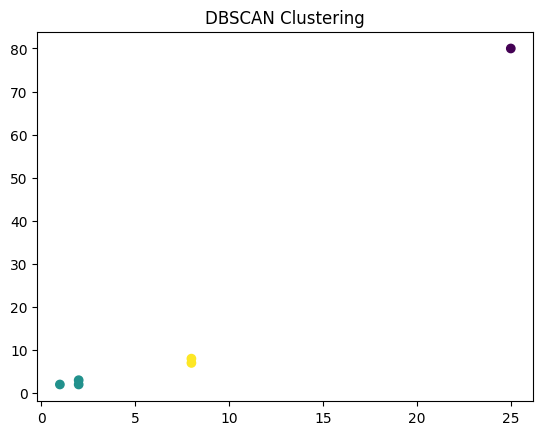

In [2]:
import numpy as np
from sklearn.cluster import DBSCAN
import matplotlib.pyplot as plt

# dataset
X = np.array([
[1,2],[2,2],[2,3],
[8,7],[8,8],[25,80]
])

model = DBSCAN(
    eps=2,
    min_samples=2
)

labels = model.fit_predict(X)

print(labels)

plt.scatter(X[:,0],X[:,1],c=labels)
plt.title("DBSCAN Clustering")
plt.show()